# Script of postprocessing plots for station files  

Example of script if you want to play with your station files and see what the validation looks like, per stations.
This script will be mainly used by WP4.

- Input file format: STATION_{STATION}_ {SCENARIO}_ {YEAR}_{MODEL}.nc 
- ICES data: {STATION}.nc (Available to download at https://drive.google.com/drive/folders/1DcjMeoq64CPLwS4GPcTTbX_H6Ip6JVIW)   

Authors: Denis P. & Capet A. 

In [110]:
import os
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [157]:
# ============================================================
# PATHS
# ============================================================

OBS_DIR = "/hpcperm/bel9956/codeblue/ICESData_for_stations/"
MODEL_DIR = "/hpcperm/bel9956/codeblue/stations/"

# ============================================================
# SELECT STATION / YEAR
# ============================================================

STATION = "TH1"
YEAR = 2012
SCENARIO = "BASE"
MODEL = "coherens"

DEPTH_BINS = [
    (0, 10),
    (10, 20),
    (20, 30),
    (30, 40),
    (40, 50),
]

VARIABLES = [var for var in model.data_vars if var in obs.data_vars] # only var that are in obs

In [153]:
VARIABLE_INFO = {
    "oxy":  {"title": "Oxygen", "units": "ml/l"},
    "nox":  {"title": "NO$_x$", "units": "µmol/l"},
    "nh4":  {"title": "NH$_4$", "units": "µmol/l"},
    "po4":  {"title": "PO$_4$", "units": "µmol/l"},
    "sio":  {"title": "Sio", "units": "µmol/l"},
    "chl":  {"title": "Chlorophyll", "units": "µg/l"},
    "temp": {"title": "Temperature", "units": "°C"},
    "sal":  {"title": "Salinity", "units": "psu"},
    "spm":  {"title": "SPM", "units": "mg/l"},
    "ph":   {"title": "pH", "units": "-"},
    "talk": {"title": "Total alkalinity", "units": "mEq/l"},
    "sec": {"title": "Secchi Depth", "units": "m"}
}

In [160]:
# --------------------------------------------------
# OBS
# --------------------------------------------------

obs_file = os.path.join(OBS_DIR, f"{STATION}.nc")
obs = xr.open_dataset(obs_file)

# Select requested year
obs_year = obs.sel(time=obs.time.dt.year == YEAR)

print("OBS:")
print(obs_year)

if obs_year.sizes["time"] == 0:
    raise ValueError(
        f"No OBS data found for {STATION} in {YEAR}. "
        "Check the observation file and selected year.")

# --------------------------------------------------
# MODEL
# --------------------------------------------------
model_file = os.path.join(MODEL_DIR, f"STATION_{STATION}_{SCENARIO}_{YEAR}_{MODEL}.nc")
model = xr.open_dataset(model_file)

print("\nMODEL:")
print(model)

OBS:
<xarray.Dataset> Size: 6kB
Dimensions:  (time: 9, depth: 9)
Coordinates:
  * time     (time) datetime64[ns] 72B 2012-01-16T11:44:00 ... 2012-12-04T11:...
  * depth    (depth) float64 72B 0.0 2.0 2.974 3.0 4.0 5.0 8.4 10.0 24.0
Data variables:
    oxy      (time, depth) float64 648B ...
    nox      (time, depth) float64 648B ...
    nh4      (time, depth) float64 648B ...
    po4      (time, depth) float64 648B ...
    sio      (time, depth) float64 648B ...
    chl      (time, depth) float64 648B ...
    temp     (time, depth) float64 648B ...
    sal      (time, depth) float64 648B ...
    ph       (time, depth) float64 648B ...
Attributes:
    station:                W04
    station_lat:            51.424988
    station_lon:            2.791595
    description:            ICES observations extracted around target station
    distance_tolerance_km:  2.0

MODEL:
<xarray.Dataset> Size: 238kB
Dimensions:  (time: 367, depth: 10, lev: 10)
Coordinates:
  * time     (time) datetime64[n

In [161]:
def depth_bin_average(ds, variable, depth_bins):
    """
    Average a variable over predefined depth bins.

    Parameters
    ----------
    ds : xarray.Dataset
        Dataset with dimensions (time, depth).
    variable : str
        Variable to average.
    depth_bins : list of tuples
        [(min_depth, max_depth), ...]

    Returns
    -------
    xarray.Dataset
        Time series of depth-bin averages.
    """

    result = {}

    depths = ds["depth"].values

    for zmin, zmax in depth_bins:

        # Find depth indices inside the bin
        depth_idx = np.where(
            (depths >= zmin) &
            (depths < zmax)
        )[0]

        label = f"{zmin}-{zmax} m"

        if len(depth_idx) == 0:
            print(f"WARNING: No depth levels found "f"for {label}")

            # Create an empty time series
            result[label] = xr.full_like(ds[variable].isel(depth=0), np.nan)

        else:
            # Select those depth levels and average
            result[label] = (ds[variable].isel(depth=depth_idx).mean(dim="depth", skipna=True))

    return xr.Dataset(result)

Plotting oxy...


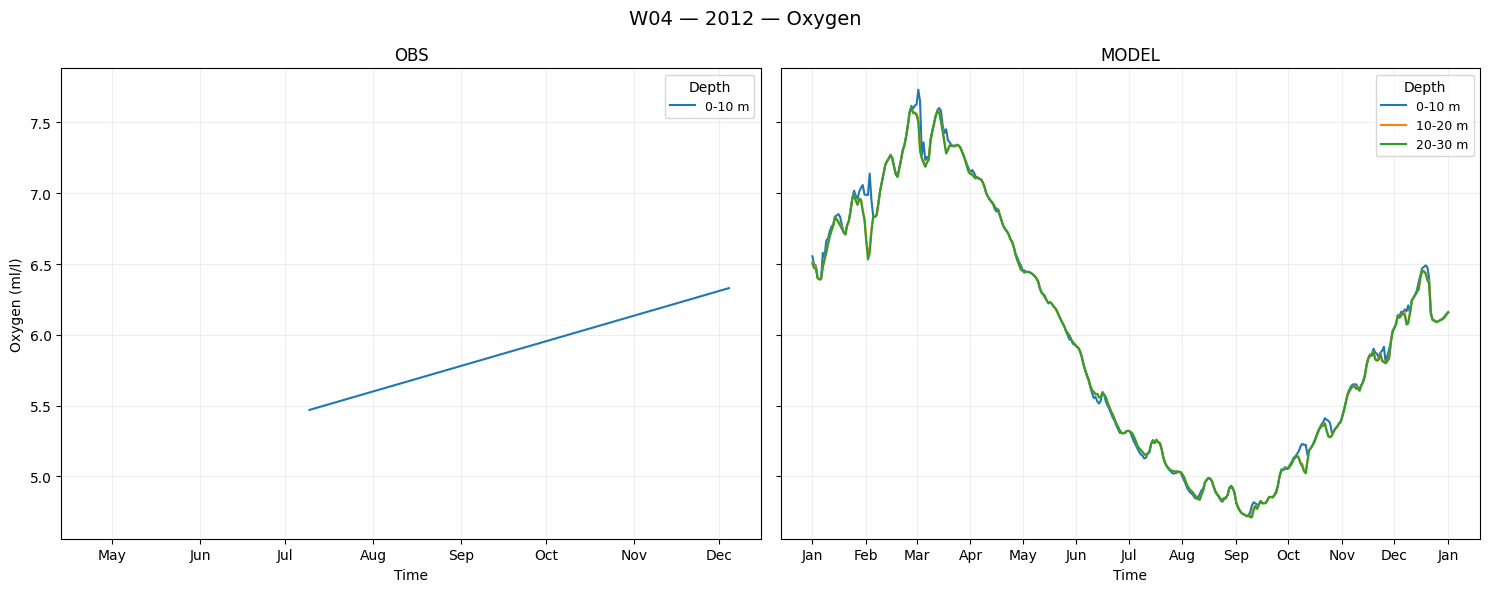

Plotting nox...


/etc/ecmwf/ssd/ssd1/jupyterhub/bel9956-jupyterhub/tmpdirs/bel9956.32049648/ipykernel_3690367/4068608189.py:57: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Depth", fontsize=9)


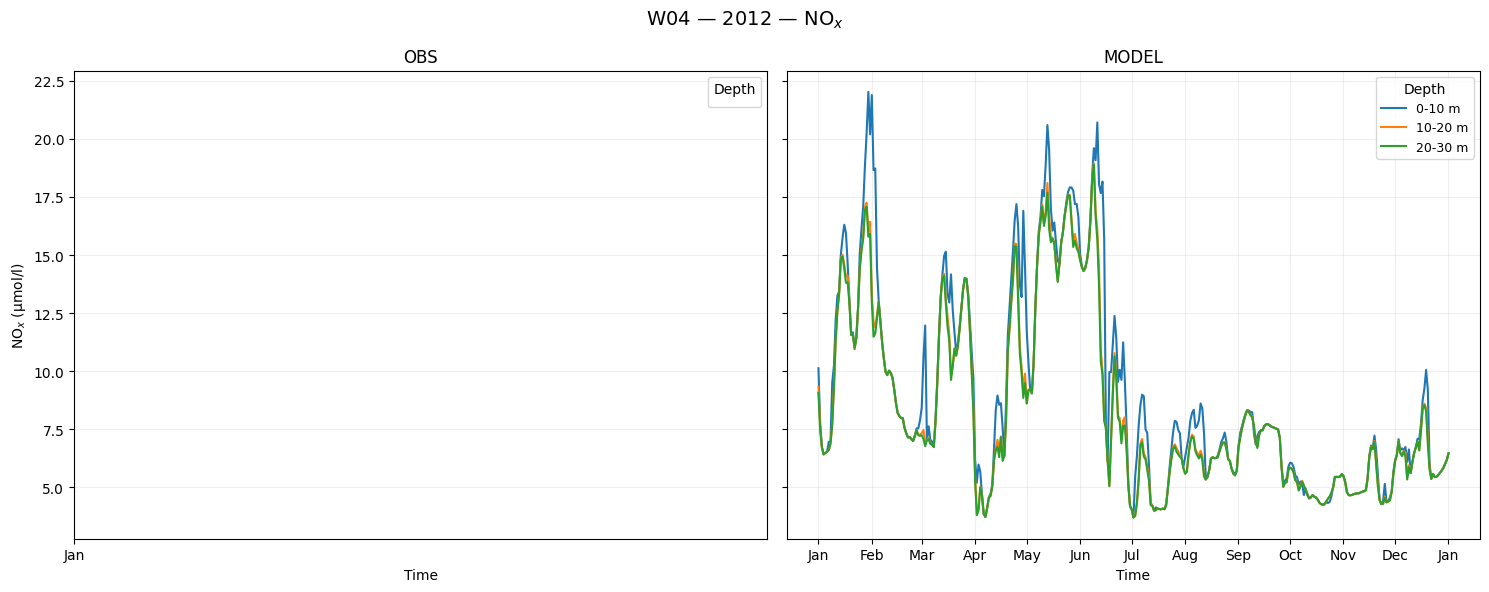

Plotting nh4...


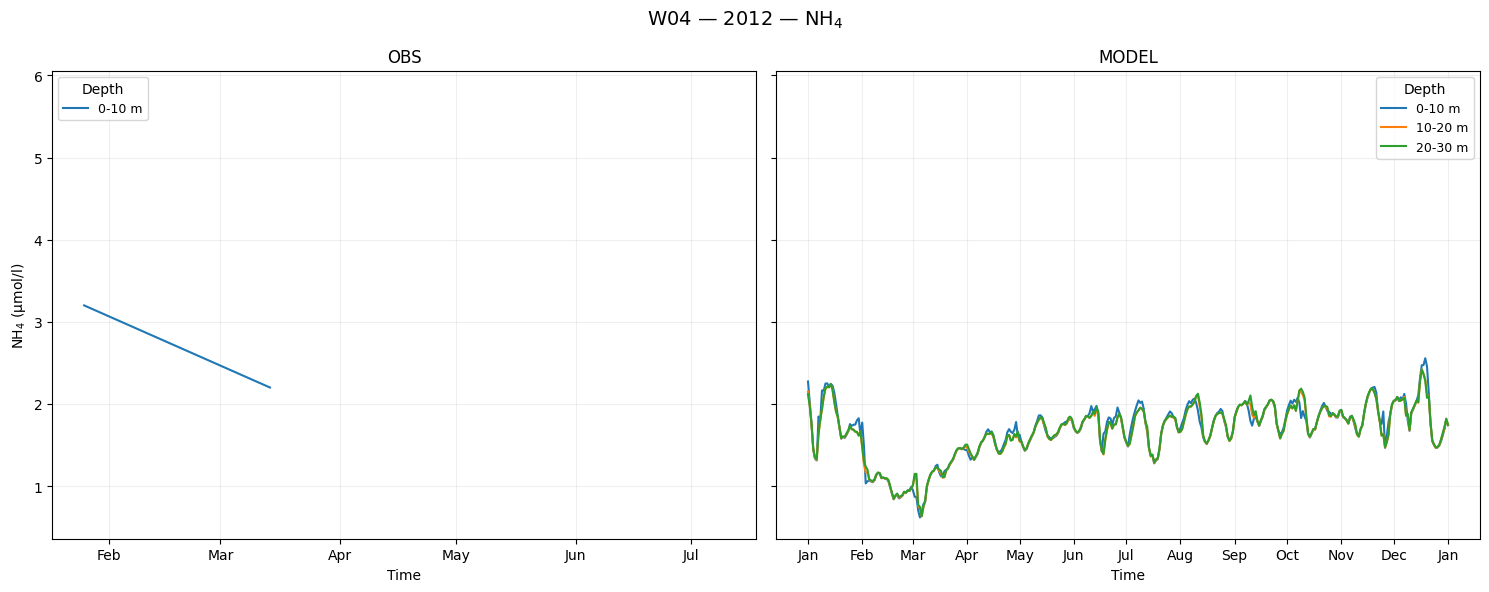

Plotting po4...


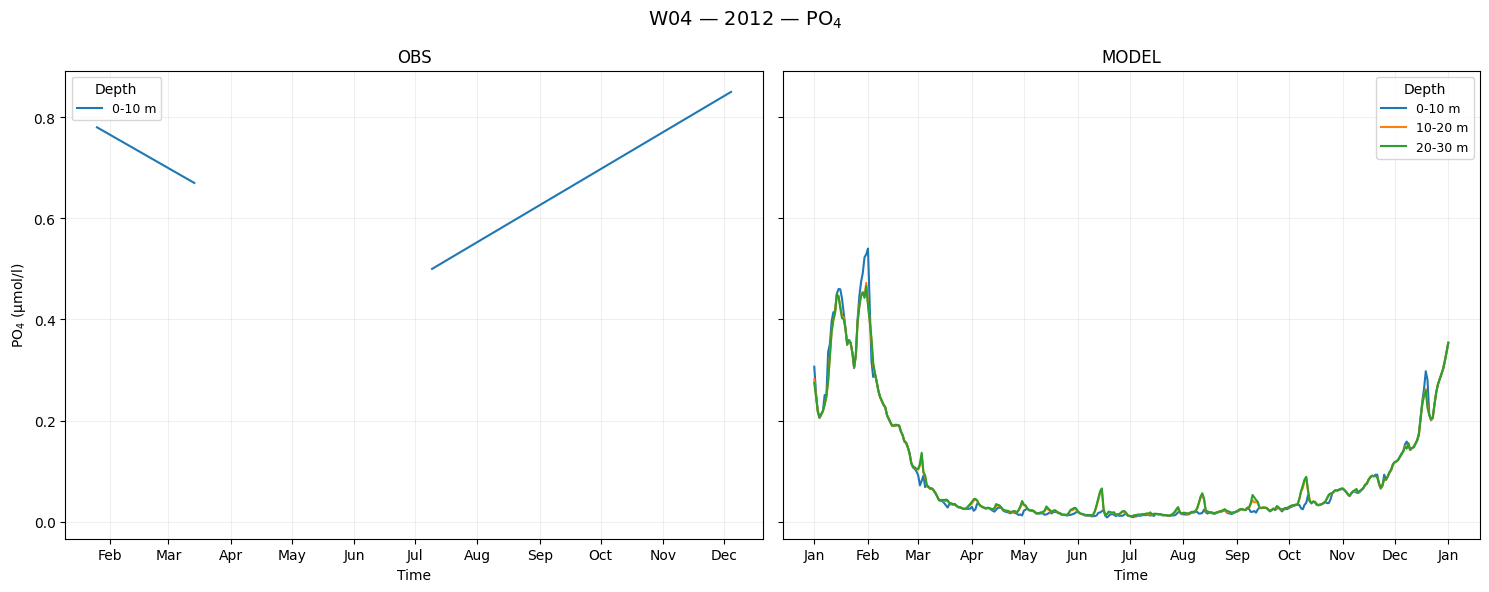

Plotting sio...


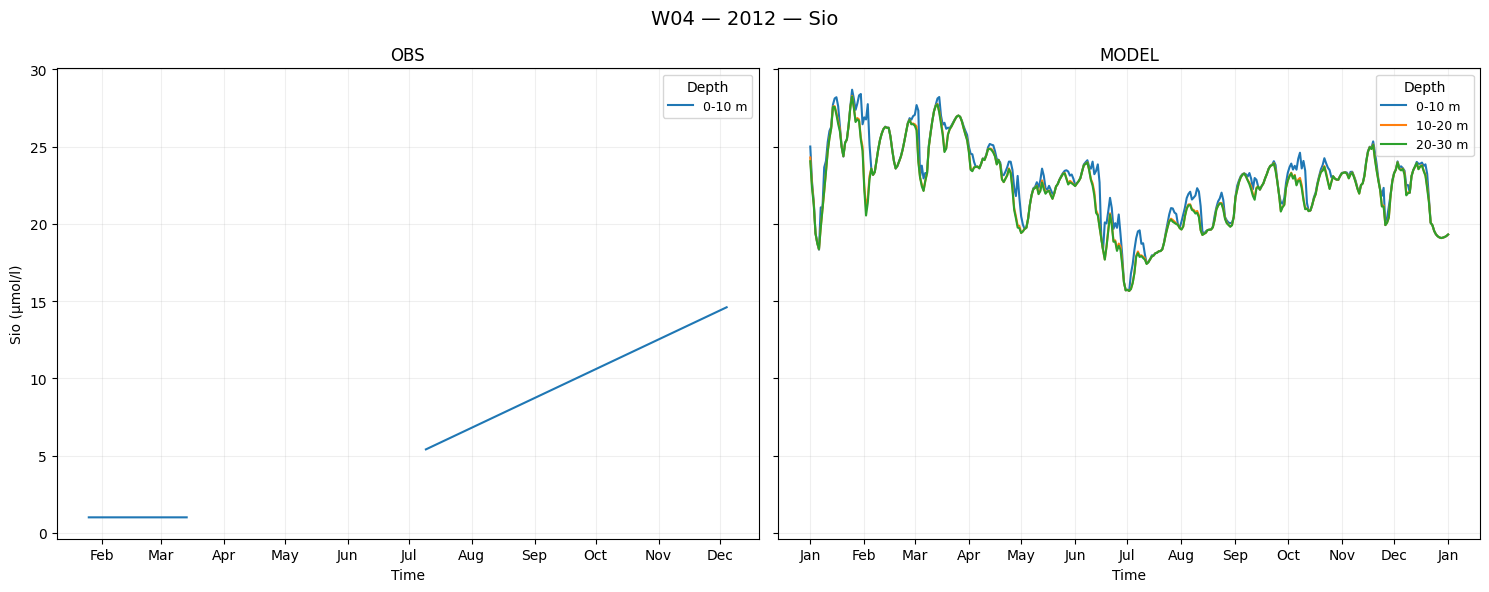

Plotting chl...


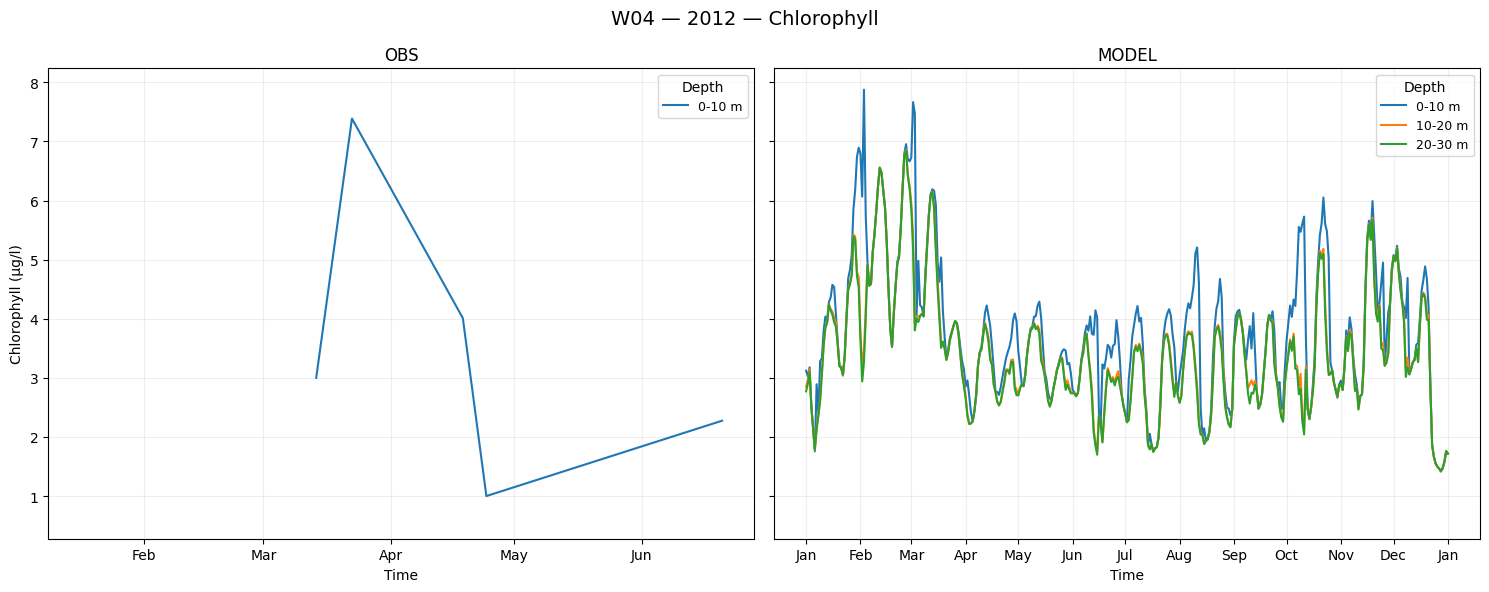

Plotting temp...


/etc/ecmwf/ssd/ssd1/jupyterhub/bel9956-jupyterhub/tmpdirs/bel9956.32049648/ipykernel_3690367/4068608189.py:57: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Depth", fontsize=9)


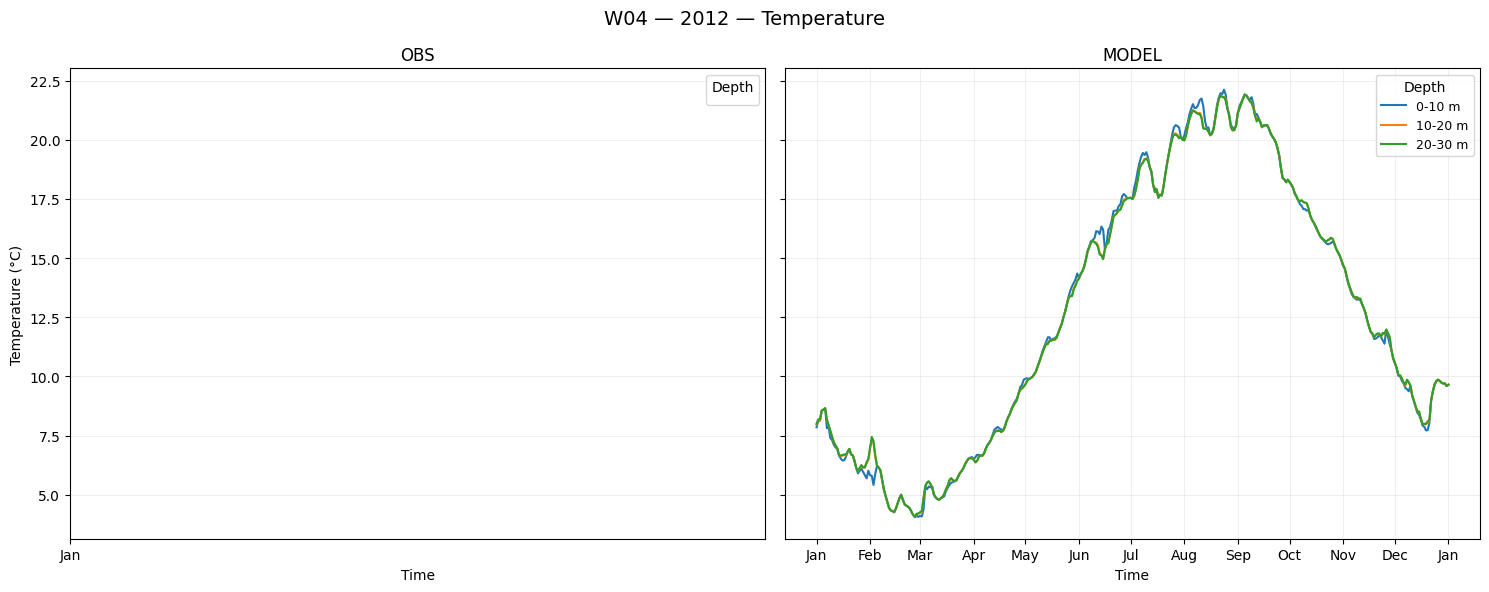

Plotting sal...


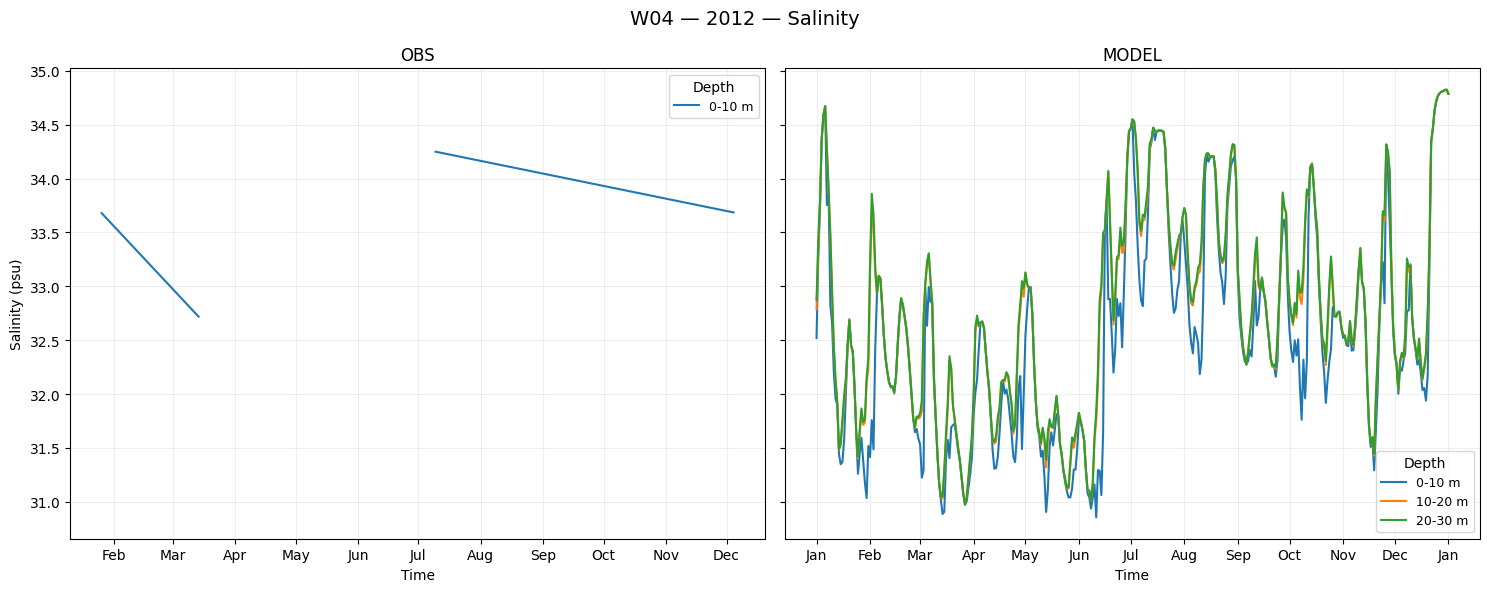

In [162]:
for VARIABLE in VARIABLES:

    print(f"Plotting {VARIABLE}...")
    # -------------------------
    # Depth-bin averages
    # -------------------------
    obs_binned = depth_bin_average(obs_year, VARIABLE, DEPTH_BINS)

    model_binned = depth_bin_average(model, VARIABLE, DEPTH_BINS)

    info = VARIABLE_INFO.get(VARIABLE, {"title": VARIABLE, "units": ""})
    title = info["title"]
    units = info["units"]

    ylabel = f"{title} ({units})" if units else title

    fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

    # =========================
    # OBS
    # =========================
    for zmin, zmax in DEPTH_BINS:

        label = f"{zmin}-{zmax} m"
        series = obs_binned[label]

        # Don't plot completely empty bins
        if np.isfinite(series.values).any():
            axes[0].plot(series["time"], series, label=label, linewidth=1.5)

    axes[0].set_title("OBS")

    # =========================
    # MODEL
    # =========================
    for zmin, zmax in DEPTH_BINS:

        label = f"{zmin}-{zmax} m"
        series = model_binned[label]

        if np.isfinite(series.values).any():
            axes[1].plot(series["time"], series, label=label, linewidth=1.5)

    axes[1].set_title("MODEL")

    # -------------------------
    # Formatting
    # -------------------------
    for ax in axes:

        ax.set_xlabel("Time")
        ax.grid(alpha=0.2)

        ax.xaxis.set_major_locator(mdates.MonthLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

        ax.legend(title="Depth", fontsize=9)

    axes[0].set_ylabel(ylabel)

    fig.suptitle(f"{STATION} — {YEAR} — {title}", fontsize=14)

    fig.tight_layout()
    plt.show()
    plt.close(fig)